# Music Genre Classification with Machine Learning

[Michelle Angelina](https://www.linkedin.com/in/mchelleangelina/)

## Libraries Import

In [138]:
# Import Library
!pip install kaggle librosa tensorflow numpy matplotlib scikit-learn pydub > /dev/null 2>&1
!apt-get install ffmpeg -y > /dev/null 2>&1
!apt-get install sox -y > /dev/null 2>&1

import torchaudio
import json
import shutil
from google.colab import files
import tkinter as tk
from tkinter import filedialog
import zipfile
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import random
import pickle
import scipy.signal
from pydub import AudioSegment
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import ipywidgets as widgets
from io import BytesIO
from IPython.display import display, Audio

In [139]:
!pip freeze > requirements.txt
!cat requirements.txt

absl-py==1.4.0
accelerate==1.3.0
aiohappyeyeballs==2.4.4
aiohttp==3.11.12
aiosignal==1.3.2
alabaster==1.0.0
albucore==0.0.23
albumentations==2.0.3
ale-py==0.10.1
altair==5.5.0
annotated-types==0.7.0
anyio==3.7.1
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array_record==0.6.0
arviz==0.20.0
astropy==7.0.0
astropy-iers-data==0.2025.2.3.0.32.42
astunparse==1.6.3
atpublic==4.1.0
attrs==25.1.0
audioread==3.0.1
autograd==1.7.0
babel==2.17.0
backcall==0.2.0
beautifulsoup4==4.13.3
bigframes==1.35.0
bigquery-magics==0.5.0
bleach==6.2.0
blinker==1.9.0
blis==0.7.11
blosc2==3.0.0
bokeh==3.6.3
Bottleneck==1.4.2
bqplot==0.12.44
branca==0.8.1
CacheControl==0.14.2
cachetools==5.5.1
catalogue==2.0.10
certifi==2025.1.31
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.1
chex==0.1.88
clarabel==0.10.0
click==8.1.8
cloudpathlib==0.20.0
cloudpickle==3.1.1
cmake==3.31.4
cmdstanpy==1.2.5
colorcet==3.1.0
colorlover==0.3.0
colour==0.1.5
community==1.0.0b1
confection==0.1.5
cons==0.4.6
contourpy==1.3.1
cr

## Data Import

In [92]:
# Upload kaggle.json
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


Data used: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/data

In [93]:
# Download dataset
!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification

# Ekstrak dataset
with zipfile.ZipFile("gtzan-dataset-music-genre-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("./data")

Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
gtzan-dataset-music-genre-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [98]:
data_path = "./data/Data/genres_original"
error_files = []

for root, _, files in os.walk(data_path):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)
            try:
                y, sr = librosa.load(file_path, sr=22050)
            except Exception as e:
                error_files.append((file_path, str(e)))

# Hapus error
for file_path, error in error_files:
    print(f"Menghapus file error: {file_path} -> {error}")
    os.remove(file_path)

valid_files = []
for root, _, files in os.walk(data_path):
    for file in files:
        if file.endswith(".wav"):
            valid_files.append(os.path.join(root, file))

print(f"Total file yang masih valid: {len(valid_files)}")

<ipython-input-98-fa2c1a249a78>:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Menghapus file error: ./data/Data/genres_original/jazz/jazz.00054.wav -> 
Total file yang masih valid: 999


In [99]:
genres = sorted(os.listdir(data_path))
print("Genres found:", genres)

Genres found: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [100]:
total_files = sum([len(files) for _, _, files in os.walk(data_path)])
print(f"Total WAV files found: {total_files}")

Total WAV files found: 999


## Data Preprocessing

### 1

In [73]:
# Ekstraksi Fitur
def extract_features(y, sr, max_pad_len=40):
    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    # Spectral Contrast
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

    # Zero-Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)

    features = np.vstack([mfcc, chroma, spec_contrast, zcr])

    # Padding
    pad_width = max_pad_len - features.shape[1]
    if pad_width > 0:
        features = np.pad(features, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        features = features[:, :max_pad_len]

    return features

# Audio Augmentation
def augment_audio(y, sr):
    augmented_data = []

    # Add Noise
    noise = 0.005 * np.random.randn(len(y))
    y_noisy = y + noise
    augmented_data.append(y_noisy)

    # Pitch shifting
    n_steps = np.random.randint(-2, 3)
    if n_steps != 0:
        y_pitch = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)
        augmented_data.append(y_pitch)

    # Time stretching
    rate = np.random.uniform(0.8, 1.2)
    if rate != 1.0:
        y_stretch = librosa.effects.time_stretch(y, rate=rate)
        augmented_data.append(y_stretch)

    return augmented_data

X, y = [], []

genres = sorted(os.listdir(data_path))
genre_labels = {genre: idx for idx, genre in enumerate(genres)}

for genre in genres:
    genre_path = os.path.join(data_path, genre)
    if os.path.isdir(genre_path):
        for file in os.listdir(genre_path):
            if file.endswith(".wav"):
                file_path = os.path.join(genre_path, file)

                try:
                    y_raw, sr = librosa.load(file_path, sr=22050)

                    # Fitur asli
                    features = extract_features(y_raw, sr)
                    X.append(features)
                    y.append(genre_labels[genre])

                    # Augmentasi
                    augmented_audios = augment_audio(y_raw, sr)
                    for audio in augmented_audios:
                        features_aug = extract_features(audio, sr)
                        X.append(features_aug)
                        y.append(genre_labels[genre])
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

X = np.array(X)
y = np.array(y)

print(f"Dataset preprocessed. Shape: X={X.shape}, y={y.shape}")
print(f"Unique classes: {np.unique(y)}")

np.save("X_features.npy", X)
np.save("y_labels.npy", y)

with open("dataset.pkl", "wb") as f:
    pickle.dump((X, y), f)

Dataset preprocessed. Shape: X=(3817, 60, 40), y=(3817,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


### 2 (Additional Augmentation by Reverb, Time Stretching, and Time Shifting)

In [112]:
# Ekstraksi Fitur
def extract_features(y, sr, max_pad_len=40):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    # Normalisasi
    features = np.vstack([mfcc, chroma, spec_contrast, spectral_rolloff])
    features = librosa.util.normalize(features)

    # Padding
    pad_width = max_pad_len - features.shape[1]
    if pad_width > 0:
        features = np.pad(features, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        features = features[:, :max_pad_len]

    return features

# Audio Augmentation
def augment_audio(y, sr):
    augmented_data = []

    # Add Noise
    noise = 0.005 * np.random.randn(len(y))
    y_noisy = y + noise
    augmented_data.append(y_noisy)

    # Pitch shifting
    n_steps = np.random.randint(-2, 3)
    if n_steps != 0:
        y_pitch = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)
        augmented_data.append(y_pitch)

    # Time stretching
    rate = np.random.uniform(0.8, 1.2)
    if rate != 1.0:
        y_stretch = librosa.effects.time_stretch(y, rate=rate)
        augmented_data.append(y_stretch)

    # Reverberation (Echo)
    impulse_response = np.zeros(sr)
    impulse_response[0] = 1
    impulse_response[int(sr * 0.3)] = 0.6
    impulse_response[int(sr * 0.6)] = 0.3

    y_reverb = scipy.signal.fftconvolve(y, impulse_response, mode='full')
    y_reverb = y_reverb[:len(y)]
    augmented_data.append(y_reverb)

    # Time Shifting
    shift = np.random.randint(sr // 10, sr // 2)
    y_shifted = np.roll(y, shift)
    augmented_data.append(y_shifted)

    return augmented_data

# Load
X, y = [], []

genres = sorted(os.listdir(data_path))
genre_labels = {genre: idx for idx, genre in enumerate(genres)}

for genre in genres:
    genre_path = os.path.join(data_path, genre)
    if os.path.isdir(genre_path):
        for file in os.listdir(genre_path):
            if file.endswith(".wav"):
                file_path = os.path.join(genre_path, file)

                try:
                    y_raw, sr = librosa.load(file_path, sr=22050)

                    # Ekstraksi Fitur Asli
                    features = extract_features(y_raw, sr)
                    X.append(features)
                    y.append(genre_labels[genre])

                    # Augmentasi
                    augmented_audios = augment_audio(y_raw, sr)
                    for audio in augmented_audios:
                        features_aug = extract_features(audio, sr)
                        X.append(features_aug)
                        y.append(genre_labels[genre])
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

X = np.array(X)
y = np.array(y)

# Simpan
np.save("X_features.npy", X)
np.save("y_labels.npy", y)

with open("dataset.pkl", "wb") as f:
    pickle.dump((X, y), f)

print(f"Dataset preprocessed. Shape: X={X.shape}, y={y.shape}")
print(f"Unique classes: {np.unique(y)}")

Dataset preprocessed. Shape: X=(5794, 60, 40), y=(5794,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


### Standardisasi

In [113]:
# Load dataset
with open("dataset.pkl", "rb") as f:
    X, y = pickle.load(f)

print(f"Loaded dataset: X={X.shape}, y={y.shape}")

# Reshape untuk Standarisasi
X = X.reshape(X.shape[0], -1)

# Standarisasi
scaler = StandardScaler()
X = scaler.fit_transform(X)

X = X.reshape(X.shape[0], 40, -1)

num_classes = len(np.unique(y))
y = to_categorical(y, num_classes=num_classes)

Loaded dataset: X=(5794, 60, 40), y=(5794,)


## Model Training

In [114]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Final X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Final X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

print("Preprocessing and splitting finished. Proceed to Model Training.")

Final X_train shape: (4635, 40, 60), y_train shape: (4635, 10)
Final X_test shape: (1159, 40, 60), y_test shape: (1159, 10)
Preprocessing and splitting finished. Proceed to Model Training.


### 1

In [78]:
# Arsitektur Model
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(40, X_train.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(128, return_sequences=True),
    LSTM(64),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compile Model
model.compile(optimizer=AdamW(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Callback
lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6, verbose=1)

# Training Model
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=[lr_reduction]
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.1836 - loss: 2.1648 - val_accuracy: 0.2013 - val_loss: 2.3534 - learning_rate: 0.0010
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.3831 - loss: 1.6912 - val_accuracy: 0.4468 - val_loss: 1.5936 - learning_rate: 0.0010
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.5812 - loss: 1.2024 - val_accuracy: 0.4828 - val_loss: 1.4600 - learning_rate: 0.0010
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7234 - loss: 0.8240 - val_accuracy: 0.6187 - val_loss: 1.1516 - learning_rate: 0.0010
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8301 - loss: 0.5482 - val_accuracy: 0.6661 - val_loss: 1.1008 - learning_rate: 0.0010
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.9026 - loss: 0.3154 - val_accuracy: 0.6678 - val_loss: 1.2014 - learning_rate: 0.0010
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9116 - loss: 0.2632 - val_accuracy: 0.7

In [79]:
# Evaluasi Training
train_loss, train_acc = model.evaluate(X_train, y_train)
print(f"Train Accuracy: {train_acc * 100:.2f}%")

# Evaluasi Testing
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9940 - loss: 0.0296
Train Accuracy: 95.22%
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7638 - loss: 1.1165
Test Accuracy: 75.39%


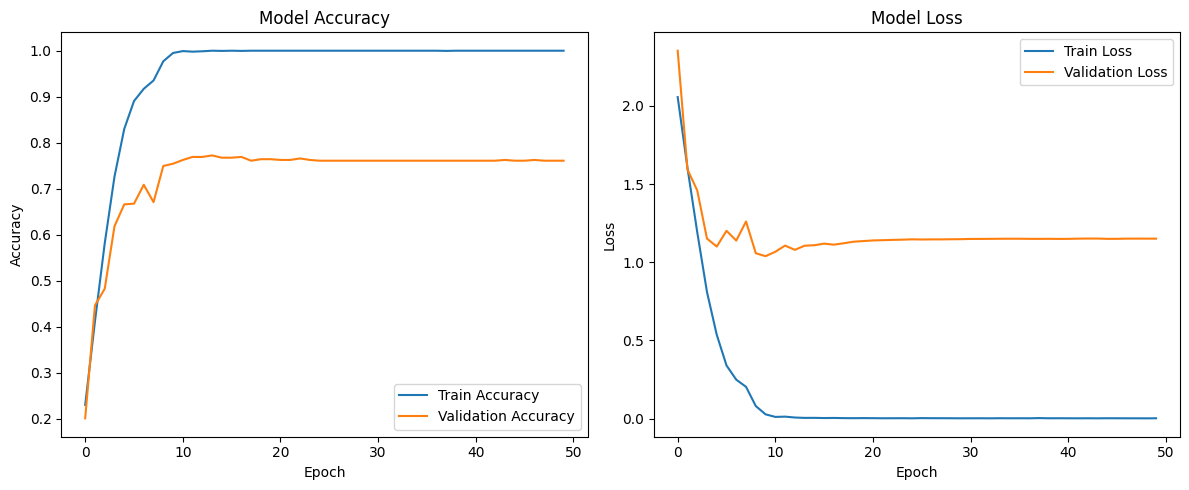

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Akurasi
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].legend()

# Plot Loss
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Validation Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].set_title('Model Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
F1 Score (Macro): 0.7554


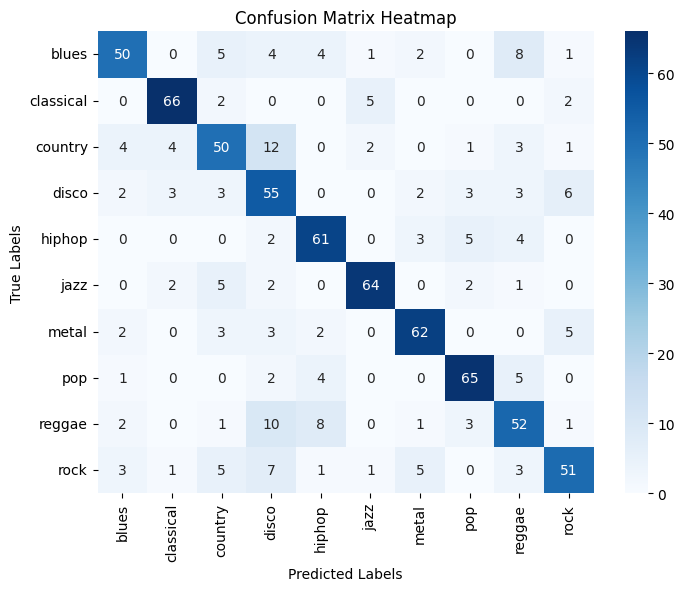

In [82]:
y_test_labels = np.argmax(y_test, axis=1)

Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)

f1 = f1_score(y_test_labels, Y_pred_classes, average='macro')
print(f'F1 Score (Macro): {f1:.4f}')

conf_matrix = confusion_matrix(y_test_labels, Y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(genre_labels.keys()),
            yticklabels=sorted(genre_labels.keys()))

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [83]:
Y_true_labels = np.argmax(y_test, axis=1)
print(classification_report(Y_true_labels, Y_pred_classes, target_names=sorted(genre_labels.keys())))

              precision    recall  f1-score   support

       blues       0.78      0.67      0.72        75
   classical       0.87      0.88      0.87        75
     country       0.68      0.65      0.66        77
       disco       0.57      0.71      0.63        77
      hiphop       0.76      0.81      0.79        75
        jazz       0.88      0.84      0.86        76
       metal       0.83      0.81      0.82        77
         pop       0.82      0.84      0.83        77
      reggae       0.66      0.67      0.66        78
        rock       0.76      0.66      0.71        77

    accuracy                           0.75       764
   macro avg       0.76      0.75      0.76       764
weighted avg       0.76      0.75      0.75       764



### 2

In [116]:
# Model Building
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(40, X_train.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Bidirectional(LSTM(128, return_sequences=True)),
    Bidirectional(LSTM(64)),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile Model
model.compile(optimizer=AdamW(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6, verbose=1)

# Training Model
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stopping, lr_reduction]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)                    │ (None, 38, 64)              │          11,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 38, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_7 (MaxPooling1D)       │ (None, 19, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_8 (Conv1D)                    │ (None, 17, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 17, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_8 (MaxPooling1D)       │ (None, 8, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 8, 256)              │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 482,378 (1.84 MB)

 Trainable params: 481,994 (1.84 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.2152 - loss: 3.0951 - val_accuracy: 0.3247 - val_loss: 2.3472 - learning_rate: 0.0010
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.3994 - loss: 2.0601 - val_accuracy: 0.4498 - val_loss: 1.7684 - learning_rate: 0.0010
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.5315 - loss: 1.5619 - val_accuracy: 0.5458 - val_loss: 1.4799 - learning_rate: 0.0010
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.6453 - loss: 1.2458 - val_accuracy: 0.5912 - val_loss: 1.3047 - learning_rate: 0.0010
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.7270 - loss: 0.9439 - val_accuracy: 0.5987 - val_loss: 1.2886 - learning_rate: 0.0010
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.7759 - loss: 0.7996 - val_accuracy: 0.6494 - val_loss: 1.1518 - learning_rate: 0.0010
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.8566 - loss

In [117]:
# Evaluasi Training
train_loss, train_acc = model.evaluate(X_train, y_train)
print(f"Train Accuracy: {train_acc * 100:.2f}%")

# Evaluasi Testing
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9945 - loss: 0.0732
Train Accuracy: 96.14%
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7677 - loss: 1.0812
Test Accuracy: 75.67%


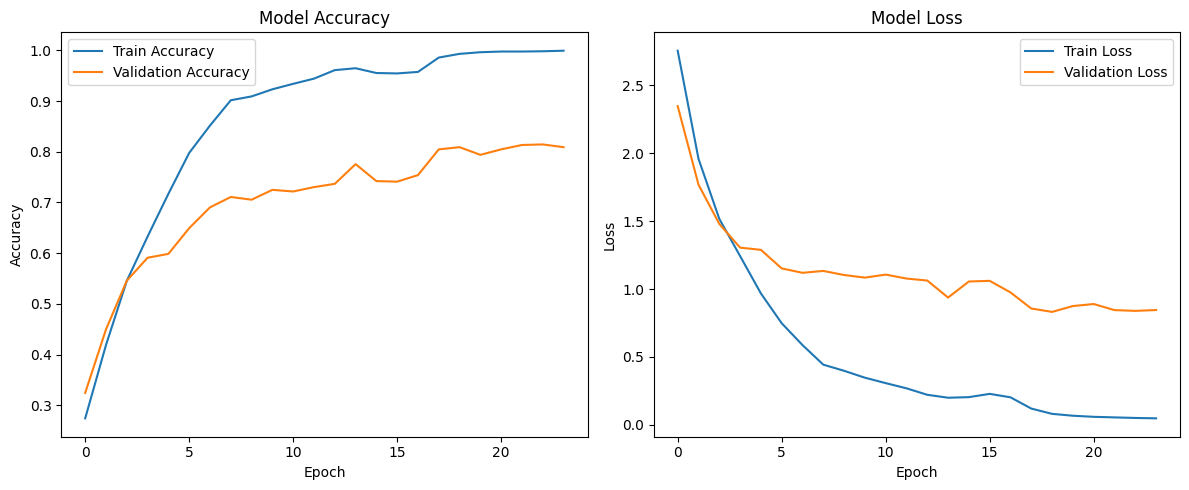

In [118]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Akurasi
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].legend()

# Plot Loss
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Validation Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].set_title('Model Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
F1 Score (Macro): 0.7567


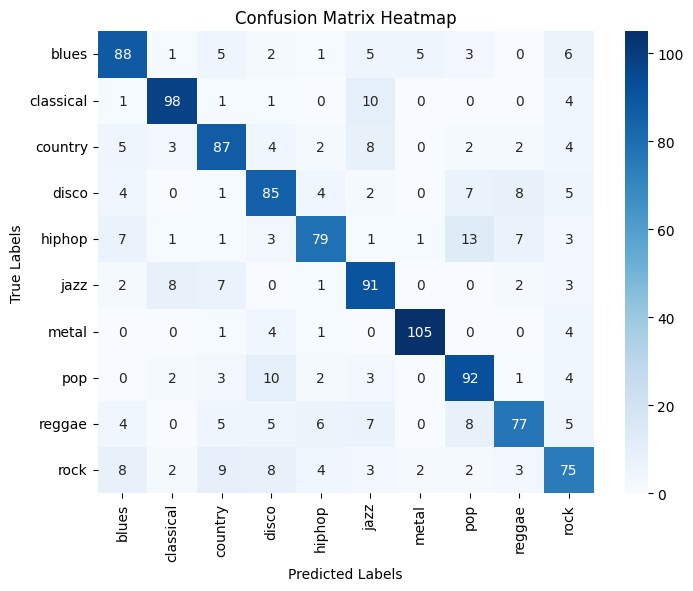

In [123]:
y_test_labels = np.argmax(y_test, axis=1)

Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)

f1 = f1_score(y_test_labels, Y_pred_classes, average='macro')
print(f'F1 Score (Macro): {f1:.4f}')

conf_matrix = confusion_matrix(y_test_labels, Y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(genre_labels.keys()),
            yticklabels=sorted(genre_labels.keys()))

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [124]:
Y_true_labels = np.argmax(y_test, axis=1)
print(classification_report(Y_true_labels, Y_pred_classes, target_names=sorted(genre_labels.keys())))

              precision    recall  f1-score   support

       blues       0.74      0.76      0.75       116
   classical       0.85      0.85      0.85       115
     country       0.72      0.74      0.73       117
       disco       0.70      0.73      0.71       116
      hiphop       0.79      0.68      0.73       116
        jazz       0.70      0.80      0.75       114
       metal       0.93      0.91      0.92       115
         pop       0.72      0.79      0.75       117
      reggae       0.77      0.66      0.71       117
        rock       0.66      0.65      0.66       116

    accuracy                           0.76      1159
   macro avg       0.76      0.76      0.76      1159
weighted avg       0.76      0.76      0.76      1159



## Model Created

### 1

In [84]:
# Simpan Model
model.save("music_genre_classifier.h5")
print("music_genre_classifier.h5 has been saved.")

music_genre_classifier.h5 has been saved.


In [87]:
# Load
model = load_model("music_genre_classifier.h5")
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
X = np.load("X_features.npy")
y = np.load("y_labels.npy")

scaler = StandardScaler()
X = X.reshape(X.shape[0], -1)
X = scaler.fit_transform(X)

# Load genre
genres = sorted(os.listdir(data_path))

def extract_features_from_audio(file_path, max_pad_len=40):
    """Ekstraksi fitur dari file audio untuk prediksi"""
    y, sr = librosa.load(file_path, sr=22050)

    # Ekstraksi
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)

    features = np.vstack([mfcc, chroma, spec_contrast, zcr])

    # Padding
    pad_width = max_pad_len - features.shape[1]
    if pad_width > 0:
        features = np.pad(features, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        features = features[:, :max_pad_len]

    return features

In [90]:
def predict_genre(file_path):
    """Fungsi untuk melakukan prediksi genre dari file audio"""
    feature = extract_features_from_audio(file_path)

    # Sesuaikan dimensi untuk model
    feature = feature.reshape(1, feature.shape[0], feature.shape[1])

    # Standarisasi fitur dengan scaler yang sudah dilatih
    feature = scaler.transform(feature.reshape(1, -1)).reshape(1, 40, -1)

    # Prediksi genre
    prediction = model.predict(feature)
    predicted_label = np.argmax(prediction)

    print(f"Predicted Genre: {genres[predicted_label]}")

# Contoh penggunaan: prediksi satu file random
random_file = random.choice(os.listdir("./data/Data/genres_original/classical"))
random_file_path = os.path.join("./data/Data/genres_original/classical", random_file)
predict_genre(random_file_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Genre: classical


### 2

In [125]:
# Simpan Model
model.save("music_genre_classifier_2.h5")
print("music_genre_classifier_2.h5 has been saved.")

music_genre_classifier_2.h5 has been saved.


In [146]:
# Load
model = load_model("music_genre_classifier_2.h5")
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
X = np.load("X_features.npy")
y = np.load("y_labels.npy")

scaler = StandardScaler()
X = X.reshape(X.shape[0], -1)
X = scaler.fit_transform(X)

# Load genre
genres = sorted(os.listdir(data_path))

def extract_features_from_audio(file_path, max_pad_len=40):
    """Ekstraksi fitur dari file audio untuk prediksi"""
    y, sr = librosa.load(file_path, sr=22050)

    # Ekstraksi
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)

    features = np.vstack([mfcc, chroma, spec_contrast, zcr])

    # Padding
    pad_width = max_pad_len - features.shape[1]
    if pad_width > 0:
        features = np.pad(features, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        features = features[:, :max_pad_len]

    return features

In [149]:
def predict_genre(file_path):
    """Fungsi untuk melakukan prediksi genre dari file audio"""
    feature = extract_features_from_audio(file_path)

    # Sesuaikan dimensi untuk model
    feature = feature.reshape(1, feature.shape[0], feature.shape[1])

    # Standarisasi fitur dengan scaler yang sudah dilatih
    feature = scaler.transform(feature.reshape(1, -1)).reshape(1, 40, -1)

    # Prediksi genre
    prediction = model.predict(feature)
    predicted_label = np.argmax(prediction)

    print(f"Predicted Genre: {genres[predicted_label]}")

# Contoh penggunaan: prediksi satu file random
random_file = random.choice(os.listdir("./data/Data/genres_original/jazz"))
random_file_path = os.path.join("./data/Data/genres_original/jazz", random_file)
predict_genre(random_file_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted Genre: jazz


Saving classical.00019.wav to classical.00019.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


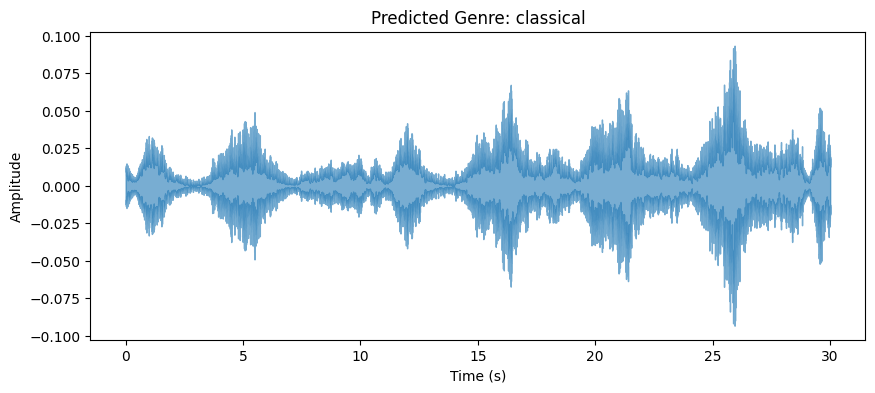

Predicted Genre: classical


In [145]:
def extract_features_from_audio(file_path, max_pad_len=40):
    y, sr = librosa.load(file_path, sr=22050)

    # Ekstraksi fitur
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)

    features = np.vstack([mfcc, chroma, spec_contrast, zcr])

    # Padding
    pad_width = max_pad_len - features.shape[1]
    if pad_width > 0:
        features = np.pad(features, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        features = features[:, :max_pad_len]

    return features, y, sr

def predict_genre(file_path):
    features, y, sr = extract_features_from_audio(file_path)

    feature = features.reshape(1, features.shape[0], features.shape[1])
    feature = scaler.transform(feature.reshape(1, -1)).reshape(1, 40, -1)
    prediction = model.predict(feature)
    predicted_label = np.argmax(prediction)

    # Plot waveform
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(y, sr=sr, alpha=0.6)
    plt.title(f'Predicted Genre: {genres[predicted_label]}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.show()

    print(f"Predicted Genre: {genres[predicted_label]}")

    # Play audio
    display(Audio(file_path, autoplay=True))

def upload_and_predict():
    uploaded = files.upload() # Kunci jawaban: metal
    for file_name in uploaded.keys():
        predict_genre(file_name)

upload_and_predict()